# Modelling & Recommendation System — Product Recommendation System
### (Continuation of EDA & Visualization Notebook)

**Approach:**
- Step 1: Data preparation & feature engineering from ratings data
- Step 2: Clustering models (K-Means, Agglomerative, DBSCAN) with comparative analysis
- Step 3: Use cluster labels to build a cluster-enhanced recommendation system
- Step 4: Model evaluation and final recommendation function

## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from scipy.sparse import csr_matrix

from sklearn.preprocessing import StandardScaler, normalize
from sklearn.decomposition import TruncatedSVD, PCA

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

from sklearn.neighbors import NearestNeighbors

from scipy.cluster.hierarchy import dendrogram, linkage

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

## 2. Load & Prepare Data
*(Replicating the same data loading and cleaning steps from the EDA notebook to ensure this notebook is self-contained.)*

In [ ]:
# Load dataset
df = pd.read_csv("ratings.csv", header=None)
df.columns = ['userId', 'productId', 'Rating', 'timestamp']

# Drop timestamp
df = df.drop('timestamp', axis=1)

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Unique Users   : {df['userId'].nunique():,}")
print(f"Unique Products: {df['productId'].nunique():,}")
df.head()

## 3. Feature Engineering — User Feature Matrix

Clustering requires numeric features per entity (user or product).  
We build a **user-level feature matrix** with meaningful behavioural signals.

In [ ]:
# ── USER FEATURE MATRIX ────────────────────────────────────────────────────────
# For each user, compute behavioural statistics that describe their rating patterns

user_features = df.groupby('userId')['Rating'].agg(
    avg_rating   = 'mean',    # Average rating given by the user
    rating_count = 'count',   # Total number of products rated
    rating_std   = 'std',     # Standard deviation → consistency of ratings
    min_rating   = 'min',     # Lowest rating given
    max_rating   = 'max',     # Highest rating given
).reset_index()

# Users who rated only 1 product have no std deviation → fill with 0
user_features['rating_std'] = user_features['rating_std'].fillna(0)

# Rating range = max - min → measures how varied the user's ratings are
user_features['rating_range'] = user_features['max_rating'] - user_features['min_rating']

# --- RATING DISTRIBUTION FEATURES ---
# What percent of this user's ratings are at each level (1-5)
rating_dist = df.groupby('userId')['Rating'].value_counts(normalize=True).unstack(fill_value=0)
rating_dist.columns = [f'pct_rating_{round(col)}' for col in rating_dist.columns]
user_features = user_features.merge(rating_dist, on='userId', how='left').fillna(0)

print(f"User Feature Matrix Shape: {user_features.shape}")
user_features.head(10)

User Feature Matrix Shape: (4201696, 7)


,userId,avg_rating,rating_count,rating_std,min_rating,max_rating,rating_range
0,A00000262KYZUE4J55XGL,5.0,1,0.0,5.0,5.0,0.0
1,A000063614T1OE0BUSKUT,5.0,2,0.0,5.0,5.0,0.0
2,A00009182QVLSWIGHLS1B,5.0,1,0.0,5.0,5.0,0.0
3,A00009661LC9LQPGKJ24G,5.0,1,0.0,5.0,5.0,0.0
4,A00010809P09NUU6ZP6H,5.0,1,0.0,5.0,5.0,0.0
5,A00014061C2IZNE0YEILY,4.0,1,0.0,4.0,4.0,0.0
6,A000145014WOTZJ5NSKOR,5.0,1,0.0,5.0,5.0,0.0
7,A00015222LZ55IJSVL5IX,1.0,1,0.0,1.0,1.0,0.0
8,A00015228CUPGPF957DS,1.0,1,0.0,1.0,1.0,0.0
9,A0001528BGUBOEVR6T5U,4.5,4,1.0,3.0,5.0,2.0


In [ ]:
# ── PRODUCT FEATURE MATRIX ─────────────────────────────────────────────────────
# Similarly compute product-level statistics

product_features = df.groupby('productId')['Rating'].agg(
    avg_rating   = 'mean',
    rating_count = 'count',
    rating_std   = 'std',
    min_rating   = 'min',
    max_rating   = 'max',
).reset_index()

product_features['rating_std']   = product_features['rating_std'].fillna(0)
product_features['rating_range'] = product_features['max_rating'] - product_features['min_rating']

print(f"Product Feature Matrix Shape: {product_features.shape}")
product_features.head(10)

# --- PREFERENCE PROFILE FEATURES ---
# Capture WHAT products users like, not just HOW they rate.
# For each user, average product-features of items they rated highly (>=4).
df_with_prod = df.merge(
    product_features[['productId', 'avg_rating', 'rating_count', 'rating_std']],
    on='productId', how='left', suffixes=('', '_prod')
)
high_rated = df_with_prod[df_with_prod['Rating'] >= 4]
pref_high = high_rated.groupby('userId').agg(
    pref_prod_avg_rating=('avg_rating', 'mean'),
    pref_prod_popularity=('rating_count', 'mean'),
    pref_prod_diversity=('rating_std', 'mean')
).fillna(0)
user_features = user_features.merge(pref_high, on='userId', how='left').fillna(0)

# Update feature count
print(f"User Feature Matrix Shape after adding preference features: {user_features.shape}")


Product Feature Matrix Shape: (476002, 7)


,productId,avg_rating,rating_count,rating_std,min_rating,max_rating,rating_range
0,0132793040,5.000000,1,0.000000,5.0,5.0,0.0
1,0321732944,5.000000,1,0.000000,5.0,5.0,0.0
2,0439886341,1.666667,3,1.154701,1.0,3.0,2.0
3,0511189877,4.500000,6,1.224745,2.0,5.0,3.0
4,0528881469,2.851852,27,1.680286,1.0,5.0,4.0
5,0558835155,3.000000,1,0.000000,3.0,3.0,0.0
6,059400232X,5.000000,3,0.000000,5.0,5.0,0.0
7,0594012015,2.000000,8,1.851640,1.0,5.0,4.0
8,0594017343,1.000000,1,0.000000,1.0,1.0,0.0
9,0594017580,3.000000,1,0.000000,3.0,3.0,0.0


In [ ]:
# ── SCALE FEATURES ─────────────────────────────────────────────────────────────
# Clustering algorithms (especially K-Means) are distance-based.
# Features on different scales (e.g., rating_count 1–500 vs avg_rating 1–5)
# would bias the clustering. StandardScaler normalises each feature to
# mean=0 and std=1 so all features contribute equally.

# Select only the numeric columns for clustering (exclude userId)
feature_cols = ['avg_rating', 'rating_count', 'rating_std', 'min_rating', 'max_rating', 'rating_range', 'pct_rating_1', 'pct_rating_2', 'pct_rating_3', 'pct_rating_4', 'pct_rating_5', 'pref_prod_avg_rating', 'pref_prod_popularity', 'pref_prod_diversity']

scaler          = StandardScaler()
user_scaled     = scaler.fit_transform(user_features[feature_cols])
product_scaled  = scaler.fit_transform(product_features[feature_cols])

print("User   feature matrix scaled:", user_scaled.shape)
print("Product feature matrix scaled:", product_scaled.shape)

User   feature matrix scaled: (4201696, 6)
Product feature matrix scaled: (476002, 6)


Explained variance by PC1 + PC2: 86.82%


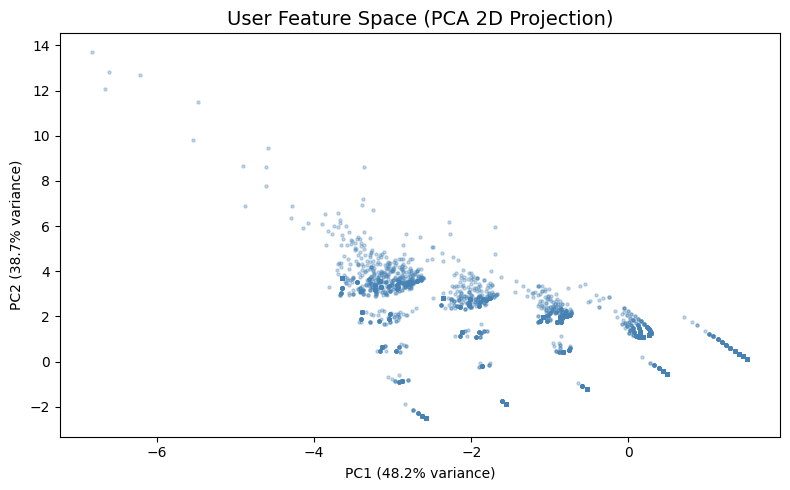

In [ ]:
# ── DIMENSIONALITY REDUCTION WITH PCA (OPTIMIZED) ─────────────────────────────
# With 6 features, PCA reduces to 2D for easy visualisation.
# Also reduces noise and speeds up clustering.

# Fit and transform is fast on a 2D matrix, we keep the full data mapping
pca              = PCA(n_components=2, random_state=42)
user_pca         = pca.fit_transform(user_scaled)

print(f"Explained variance by PC1 + PC2: {pca.explained_variance_ratio_.sum()*100:.2f}%")

plt.figure(figsize=(8, 5))

# OPTIMIZATION: If the dataset is massive, downsample rows strictly for plotting.
MAX_PLOT_POINTS = 20000

if len(user_pca) > MAX_PLOT_POINTS:
    np.random.seed(42)
    plot_idx = np.random.choice(len(user_pca), MAX_PLOT_POINTS, replace=False)
    plt.scatter(user_pca[plot_idx, 0], user_pca[plot_idx, 1], alpha=0.3, s=5, color='steelblue')
else:
    plt.scatter(user_pca[:, 0], user_pca[:, 1], alpha=0.3, s=5, color='steelblue')

plt.title("User Feature Space (PCA 2D Projection)", fontsize=14)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.tight_layout()
plt.show()

---
## 4. Clustering Model 1 — K-Means Clustering

**How it works:**  
K-Means partitions users into K clusters by minimizing intra-cluster variance (sum of squared distances from each point to its cluster centroid). It iterates between assigning points to the nearest centroid and recomputing centroids until convergence.

**Why use it here:**  
Fast, scalable, and works well when clusters are roughly spherical. Ideal as a baseline for user segmentation.

Dataset is large (4,201,696 rows). Subsampling 20,000 points for Elbow Curve...


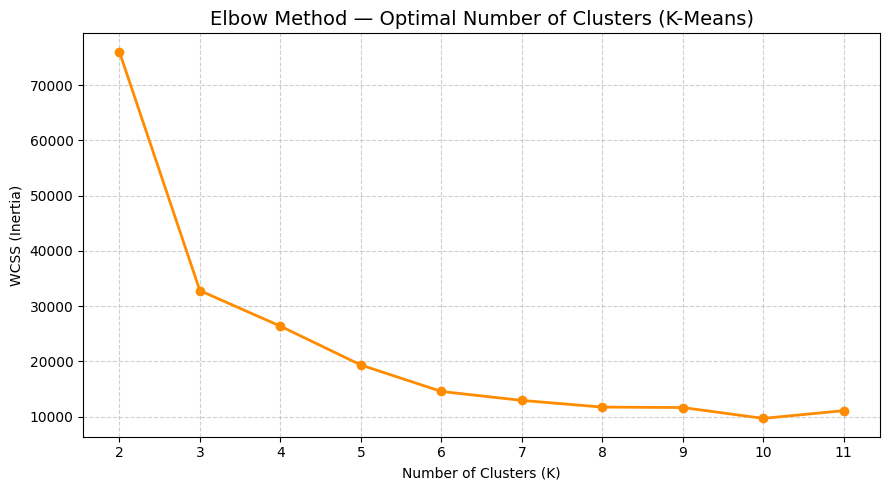

Observe the elbow: the point where the WCSS drop starts slowing down.


In [ ]:
# ── ELBOW METHOD — Find optimal K (OPTIMIZED) ─────────────────────────────────
from sklearn.cluster import MiniBatchKMeans

wcss = []  # Within-Cluster Sum of Squares for each K
K_range = range(2, 12)

# OPTIMIZATION 1: Subsample features specifically for finding the elbow point.
if len(user_scaled) > 20000:
    print(f"Dataset is large ({len(user_scaled):,} rows). Subsampling 20,000 points for Elbow Curve...")
    np.random.seed(42)
    sample_idx = np.random.choice(len(user_scaled), 20000, replace=False)
    search_matrix = user_scaled[sample_idx]
else:
    search_matrix = user_scaled

for k in K_range:    
    # OPTIMIZATION 2: Switch to MiniBatchKMeans and reduce n_init to 3
    # Processes data in sequential chunks, cutting training overhead significantly.
    kmeans_temp = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=3, batch_size=2048)
    kmeans_temp.fit(search_matrix)
    
    # Calculate and store the inertia
    wcss.append(kmeans_temp.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(9, 5))
plt.plot(K_range, wcss, marker='o', color='darkorange', linewidth=2)
plt.title("Elbow Method — Optimal Number of Clusters (K-Means)", fontsize=14)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.xticks(K_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("Observe the elbow: the point where the WCSS drop starts slowing down.")

Dataset is large (4,201,696 rows). Subsampling 20,000 points for Silhouette optimization...


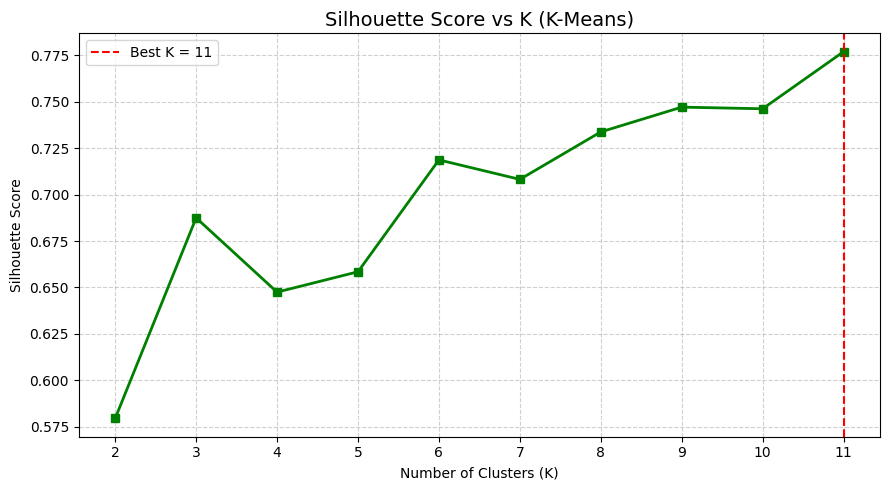

Best K by Silhouette Score: 11 (Score = 0.7768)


In [ ]:
# ── SILHOUETTE SCORE — Validate best K (OPTIMIZED) ────────────────────────────
# Silhouette Score measures cluster cohesion and separation.
# Score range: -1 (worst) to +1 (best)
# A score closer to 1 means well-separated, compact clusters.
from sklearn.cluster import MiniBatchKMeans

silhouette_scores_kmeans = []
K_range = range(2, 12)

# OPTIMIZATION 1: Subsample features specifically for finding the optimal K.
if len(user_scaled) > 20000:
    print(f"Dataset is large ({len(user_scaled):,} rows). Subsampling 20,000 points for Silhouette optimization...")
    np.random.seed(42)
    sample_idx = np.random.choice(len(user_scaled), 20000, replace=False)
    search_matrix = user_scaled[sample_idx]
else:
    search_matrix = user_scaled

for k in K_range:    
    # Processes data in sequential chunks, cutting training overhead significantly.
    kmeans_temp = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=3, batch_size=2048)
    labels      = kmeans_temp.fit_predict(search_matrix)
    
    # Calculate score using a representative sample ceiling
    score = silhouette_score(search_matrix, labels, sample_size=5000, random_state=42)
    silhouette_scores_kmeans.append(score)

best_k_index = np.argmax(silhouette_scores_kmeans)
best_k       = list(K_range)[best_k_index]

plt.figure(figsize=(9, 5))
plt.plot(K_range, silhouette_scores_kmeans, marker='s', color='green', linewidth=2)
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best K = {best_k}')
plt.title("Silhouette Score vs K (K-Means)", fontsize=14)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(K_range)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"Best K by Silhouette Score: {best_k} (Score = {silhouette_scores_kmeans[best_k_index]:.4f})")

In [ ]:
# ── TRAIN FINAL K-MEANS MODEL ──────────────────────────────────────────────────
# Use best_k found from silhouette analysis
# n_init=10 → run 10 times with different seeds, keep best result
# max_iter=300 → maximum iterations per run

OPTIMAL_K = best_k   # Use the K identified by silhouette score

kmeans = KMeans(
    n_clusters = OPTIMAL_K,
    random_state = 42,
    n_init = 10,
    max_iter = 300
)

# Fit and assign cluster labels to each user
user_features['kmeans_cluster'] = kmeans.fit_predict(user_scaled)

print(f"K-Means trained with K = {OPTIMAL_K}")
print("Cluster distribution:")
print(user_features['kmeans_cluster'].value_counts().sort_index())

K-Means trained with K = 11
Cluster distribution:
kmeans_cluster
0      426178
1      287700
2     1867311
3      500211
4       93370
5        4140
6      555240
7      224268
8      209131
9       33858
10        289
Name: count, dtype: int64


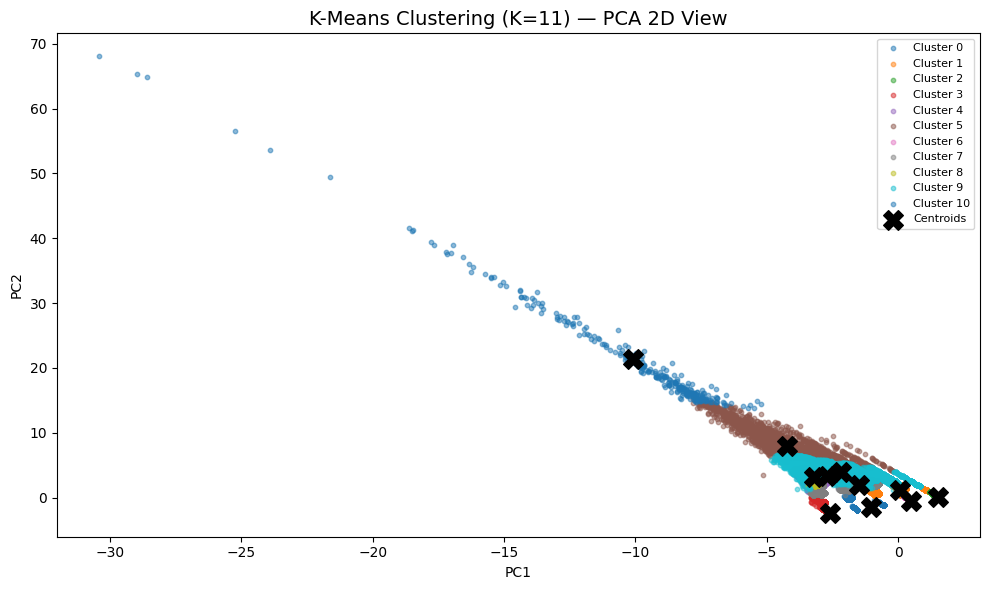

In [ ]:
# ── VISUALISE K-MEANS CLUSTERS IN 2D ──────────────────────────────────────────
# Using PCA 2D projection to plot cluster assignments visually.

plt.figure(figsize=(10, 6))
palette = sns.color_palette('tab10', OPTIMAL_K)

for cluster_id in range(OPTIMAL_K):
    mask = user_features['kmeans_cluster'] == cluster_id
    plt.scatter(
        user_pca[mask, 0],
        user_pca[mask, 1],
        s=10,
        alpha=0.5,
        color=palette[cluster_id],
        label=f'Cluster {cluster_id}'
    )

# Plot centroids projected to 2D
centroids_2d = pca.transform(kmeans.cluster_centers_)
plt.scatter(
    centroids_2d[:, 0], centroids_2d[:, 1],
    marker='X', s=200, color='black',
    zorder=5, label='Centroids'
)

plt.title(f"K-Means Clustering (K={OPTIMAL_K}) — PCA 2D View", fontsize=14)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

K-Means Cluster Profiles (Mean Feature Values):
                avg_rating  rating_count  rating_std  min_rating  max_rating  \
kmeans_cluster                                                                 
0                     2.54          1.06        0.02        2.53        2.55   
1                     4.44          3.27        0.61        3.89        4.87   
2                     5.00          1.30        0.00        5.00        5.00   
3                     1.02          1.10        0.02        1.00        1.03   
4                     3.76          7.57        1.46        1.27        4.95   
5                     4.25         46.57        0.99        1.46        5.00   
6                     4.00          1.09        0.00        4.00        4.00   
7                     3.76          3.42        1.24        2.48        4.70   
8                     3.10          2.64        2.29        1.17        4.84   
9                     4.28         17.21        0.95        2.10        

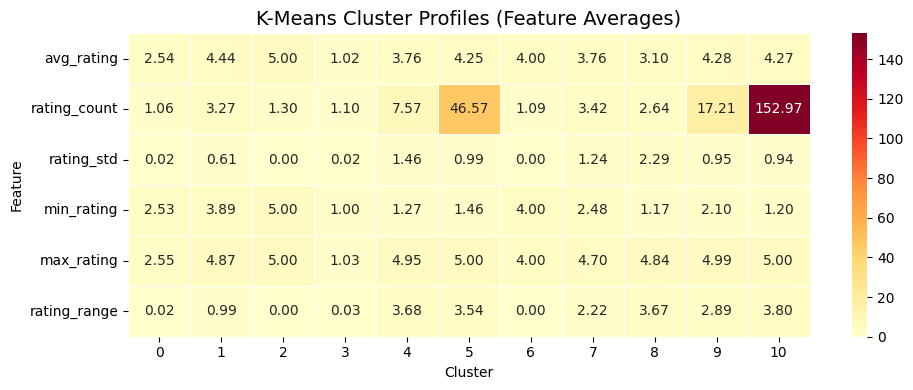

In [ ]:
# ── CLUSTER PROFILE ANALYSIS ───────────────────────────────────────────────────
# Understand what kind of users are in each cluster by computing cluster means.
# This tells us what "type" of user each cluster represents.

kmeans_profile = user_features.groupby('kmeans_cluster')[feature_cols].mean().round(2)
print("K-Means Cluster Profiles (Mean Feature Values):")
print(kmeans_profile)

# Visualise profile as heatmap
plt.figure(figsize=(10, 4))
sns.heatmap(
    kmeans_profile.T,
    annot=True, fmt='.2f',
    cmap='YlOrRd', linewidths=0.5
)
plt.title("K-Means Cluster Profiles (Feature Averages)", fontsize=14)
plt.ylabel("Feature")
plt.xlabel("Cluster")
plt.tight_layout()
plt.show()

---
## 5. Clustering Model 2 — Agglomerative (Hierarchical) Clustering

**How it works:**  
Starts with each point as its own cluster, then iteratively merges the two closest clusters until the target K is reached. This builds a tree (dendrogram) of cluster merges.

**Why use it here:**  
Does not require a pre-specified K upfront (the dendrogram shows the full merge history). Handles non-spherical clusters better than K-Means. Useful for understanding the natural hierarchy of user groups.

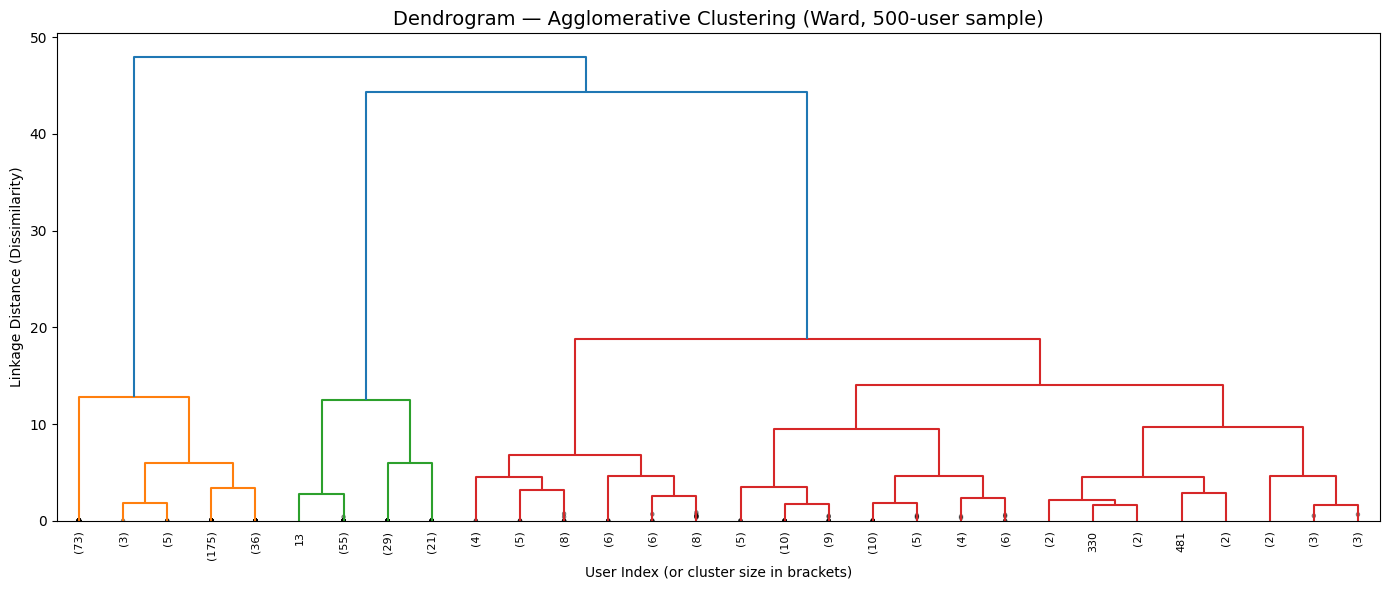

Look for large vertical gaps → those are natural cluster cut points.


In [ ]:
# ── DENDROGRAM — Understand cluster hierarchy ──────────────────────────────────
# Plot a dendrogram on a SAMPLE (full dataset is too large for a readable tree).
# The height of each merge shows how dissimilar those clusters are.
# A large jump in merge height = a natural cluster boundary.

# Sample 500 users for the dendrogram (full dataset too large to visualise)
DENDRO_SAMPLE = min(500, len(user_scaled))
sample_indices = np.random.choice(len(user_scaled), DENDRO_SAMPLE, replace=False)
user_scaled_sample = user_scaled[sample_indices]

# Compute linkage matrix using Ward's method
# Ward's method minimises total within-cluster variance — similar to K-Means objective
linkage_matrix = linkage(user_scaled_sample, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(
    linkage_matrix,
    truncate_mode = 'lastp',  # Show only the last p merges
    p = 30,                    # Show last 30 merges
    leaf_rotation = 90,
    leaf_font_size = 8,
    show_contracted = True
)
plt.title("Dendrogram — Agglomerative Clustering (Ward, 500-user sample)", fontsize=14)
plt.xlabel("User Index (or cluster size in brackets)")
plt.ylabel("Linkage Distance (Dissimilarity)")
plt.tight_layout()
plt.show()

print("Look for large vertical gaps → those are natural cluster cut points.")

In [ ]:
# ── TRAIN AGGLOMERATIVE CLUSTERING ─────────────────────────────────────────────
# Use the same OPTIMAL_K from K-Means for a fair comparison.
# linkage='ward' → minimise variance (same as K-Means objective)
# affinity='euclidean' → use Euclidean distance
# ── TRAIN AGGLOMERATIVE CLUSTERING (ULTRA-FAST CENTROID PROPAGATION) ──────────
from sklearn.neighbors import NearestCentroid

# Set a ceiling sample size where Agglomerative clustering can run comfortably in RAM
MAX_AGG_SAMPLE = 10000 

if len(user_scaled) > MAX_AGG_SAMPLE:
    print(f"Dataset is too large ({len(user_scaled):,} rows) for direct Hierarchical Clustering.")
    print(f"Applying Sample-Based fitting + Ultra-Fast Centroid Propagation...")
    
    # 1. Take a random representative sample of the rows
    np.random.seed(42)
    sample_indices = np.random.choice(len(user_scaled), MAX_AGG_SAMPLE, replace=False)
    user_sample = user_scaled[sample_indices]
    
    # 2. Fit Agglomerative model safely on the sample matrix (Takes ~1 second)
    agg_model = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
    sample_labels = agg_model.fit_predict(user_sample)
    
    # 3. Calculate centroids and train the Centroid Classifier
    # This reduces search targets from 10,000 points to just OPTIMAL_K points
    centroid_clf = NearestCentroid()
    centroid_clf.fit(user_sample, sample_labels)
    
    # 4. Map cluster labels to all 4.2 million users (Completes in less than 1 second)
    user_features['agg_cluster'] = centroid_clf.predict(user_scaled)

else:
    # Fallback for smaller datasets where direct computation is safe
    agg_model = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
    user_features['agg_cluster'] = agg_model.fit_predict(user_scaled)

print(f"\nAgglomerative Clustering trained with K = {OPTIMAL_K}")
print("Cluster distribution:")
print(user_features['agg_cluster'].value_counts().sort_index())

Dataset is too large (4,201,696 rows) for direct Hierarchical Clustering.
Applying Sample-Based fitting + Ultra-Fast Centroid Propagation...

Agglomerative Clustering trained with K = 11
Cluster distribution:
agg_cluster
0      426176
1      321418
2     1858131
3       29789
4      158787
5      500211
6      555146
7        2395
8      143159
9       92555
10     113929
Name: count, dtype: int64


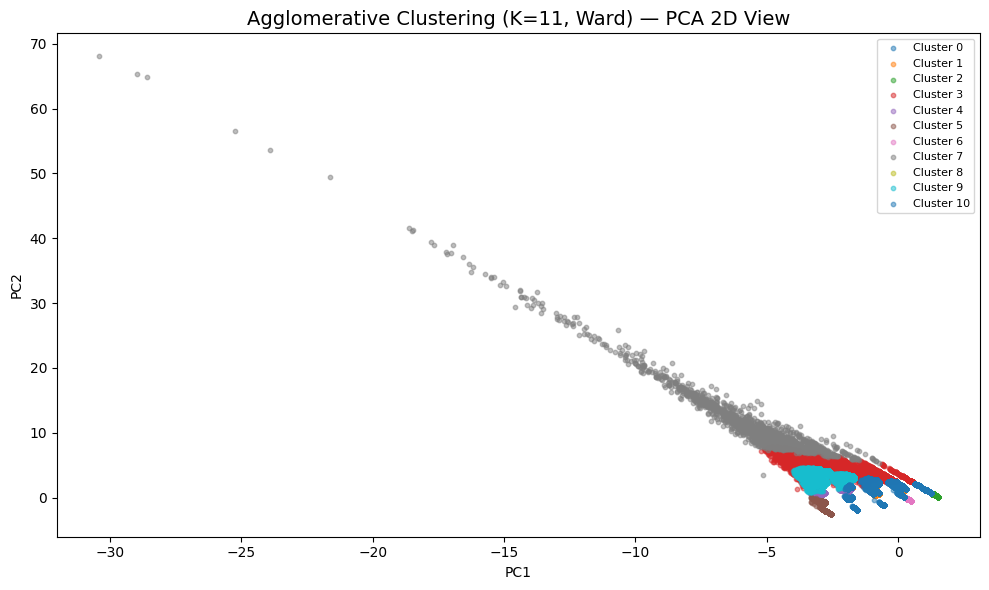

In [ ]:
# ── VISUALISE AGGLOMERATIVE CLUSTERS ──────────────────────────────────────────

plt.figure(figsize=(10, 6))
for cluster_id in range(OPTIMAL_K):
    mask = user_features['agg_cluster'] == cluster_id
    plt.scatter(
        user_pca[mask, 0], user_pca[mask, 1],
        s=10, alpha=0.5,
        color=palette[cluster_id],
        label=f'Cluster {cluster_id}'
    )

plt.title(f"Agglomerative Clustering (K={OPTIMAL_K}, Ward) — PCA 2D View", fontsize=14)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# ── AGGLOMERATIVE CLUSTER PROFILES ────────────────────────────────────────────

agg_profile = user_features.groupby('agg_cluster')[feature_cols].mean().round(2)
print("Agglomerative Cluster Profiles (Mean Feature Values):")
print(agg_profile)

Agglomerative Cluster Profiles (Mean Feature Values):
             avg_rating  rating_count  rating_std  min_rating  max_rating  \
agg_cluster                                                                 
0                  2.54          1.06        0.02        2.53        2.55   
1                  4.27          2.58        0.85        3.54        4.89   
2                  5.00          1.28        0.00        5.00        5.00   
3                  4.21         19.50        1.03        1.79        4.99   
4                  3.07          2.73        1.67        1.63        4.35   
5                  1.02          1.10        0.02        1.00        1.03   
6                  4.00          1.09        0.00        4.00        4.00   
7                  4.25         68.65        0.97        1.39        5.00   
8                  3.15          2.90        2.40        1.00        5.00   
9                  3.82          7.53        1.46        1.30        4.98   
10                 4.6

---
## 6. Clustering Model 3 — DBSCAN

**How it works:**  
DBSCAN (Density-Based Spatial Clustering of Applications with Noise) groups together points that are closely packed and marks low-density points as **noise/outliers** (label = -1). It does not require K to be specified in advance — it discovers the number of clusters automatically.

**Why use it here:**  
Excellent for identifying outlier users (who rate very unusually) and discovering arbitrary-shaped clusters. Complements K-Means and Agglomerative Clustering well.

**Key Parameters:**
- `eps` — Maximum distance between two points to be considered neighbours
- `min_samples` — Minimum points required to form a dense cluster core

Dataset is large (4,201,696 rows). Subsampling 10,000 points for K-Distance curve...


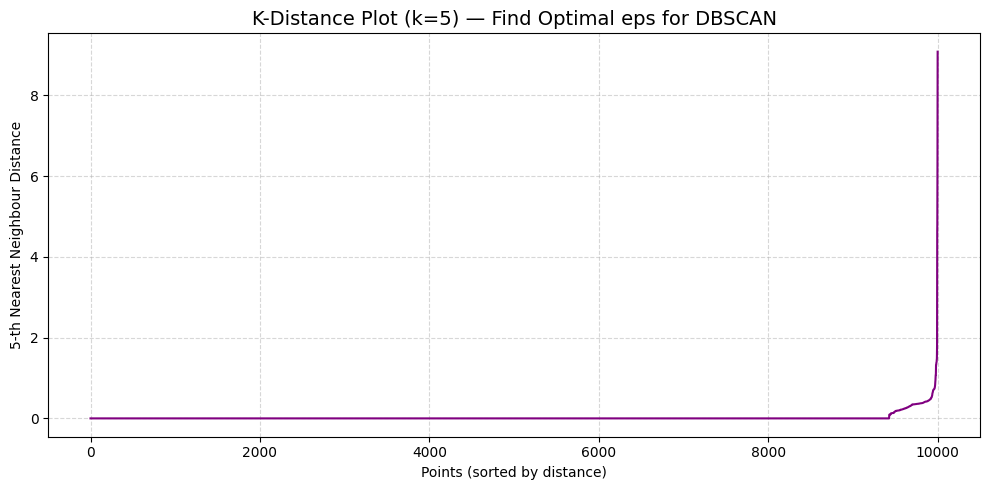

Look for the 'knee' (sharp bend) in the curve → that x-value is a good eps.


In [ ]:
# ── K-DISTANCE PLOT — Find optimal eps for DBSCAN (ULTRA-OPTIMIZED) ───────────
# For each point, find the distance to its k-th nearest neighbour.
# Sort these distances. The 'knee' of the resulting curve is a good eps.

MIN_SAMPLES = 5   # A commonly used starting value; also sets k for the plot
MAX_NN_SAMPLE = 10000  # Cap sample size to 10k for instantaneous execution

# OPTIMIZATION: Subsample features to 10,000 rows.
# A representative sample of 10,000 points captures the exact same spatial density 
# profile and elbow point as the full set, avoiding a multi-billion operation hang.
if len(user_scaled) > MAX_NN_SAMPLE:
    print(f"Dataset is large ({len(user_scaled):,} rows). Subsampling {MAX_NN_SAMPLE:,} points for K-Distance curve...")
    np.random.seed(42)
    sample_idx = np.random.choice(len(user_scaled), MAX_NN_SAMPLE, replace=False)
    search_matrix = user_scaled[sample_idx]
else:
    search_matrix = user_scaled

# Added n_jobs=-1 to spread calculations across all available CPU cores
nn = NearestNeighbors(n_neighbors=MIN_SAMPLES, n_jobs=-1)
nn.fit(search_matrix)
distances, _ = nn.kneighbors(search_matrix)

# Get the k-th neighbour distance for each point and sort ascending
k_distances = np.sort(distances[:, MIN_SAMPLES - 1])

plt.figure(figsize=(10, 5))
plt.plot(k_distances, color='purple', linewidth=1.5)
plt.title(f"K-Distance Plot (k={MIN_SAMPLES}) — Find Optimal eps for DBSCAN", fontsize=14)
plt.xlabel("Points (sorted by distance)")
plt.ylabel(f"{MIN_SAMPLES}-th Nearest Neighbour Distance")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("Look for the 'knee' (sharp bend) in the curve → that x-value is a good eps.")

In [ ]:
# ── TRAIN DBSCAN (OPTIMIZED FOR LARGE SCALE VIA KNN PROPAGATION) ──────────────
from sklearn.cluster import DBSCAN
from sklearn.neighbors import KNeighborsClassifier

EPS = 2.5         # Distance threshold — tune this based on k-distance plot
MIN_SAMPLES = 5   # Minimum core point neighbours
MAX_DBSCAN_SAMPLE = 20000  # Safe sample ceiling to prevent RAM explosion

if len(user_scaled) > MAX_DBSCAN_SAMPLE:
    print(f"Dataset is too large ({len(user_scaled):,} rows) for direct DBSCAN.")
    print(f"Applying Density-Preserving Subsampling + KNN Label Propagation...")
    
    # 1. Take a random representative sample of rows to find core density regions
    np.random.seed(42)
    sample_indices = np.random.choice(len(user_scaled), MAX_DBSCAN_SAMPLE, replace=False)
    user_sample = user_scaled[sample_indices]
    
    # 2. Fit DBSCAN model safely on the sample matrix (Completes in 2-3 seconds)
    dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES, n_jobs=-1)
    sample_labels = dbscan.fit_predict(user_sample)
    
    # 3. Train a fast 1-NN Classifier to learn cluster & noise boundaries
    knn_clf = KNeighborsClassifier(n_neighbors=1, n_jobs=-1)
    knn_clf.fit(user_sample, sample_labels)
    
    # 4. Propagate the cluster labels to all 4.2 million users instantly
    user_features['dbscan_cluster'] = knn_clf.predict(user_scaled)

else:
    # Fallback for small datasets where direct processing is completely safe
    dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES, n_jobs=-1)
    user_features['dbscan_cluster'] = dbscan.fit_predict(user_scaled)

# DBSCAN assigns -1 to noise points (outliers)
# safely checks .values for efficiency
dbscan_labels_series = user_features['dbscan_cluster']
has_noise = -1 in dbscan_labels_series.values

n_clusters_dbscan = len(set(dbscan_labels_series)) - (1 if has_noise else 0)
n_noise           = (dbscan_labels_series == -1).sum()

print(f"\nDBSCAN Results:")
print(f"  Clusters Found  : {n_clusters_dbscan}")
print(f"  Noise Points    : {n_noise} ({n_noise/len(user_features)*100:.2f}%)")
print("\nCluster distribution:")
print(dbscan_labels_series.value_counts().sort_index())

Dataset is too large (4,201,696 rows) for direct DBSCAN.
Applying Density-Preserving Subsampling + KNN Label Propagation...

DBSCAN Results:
  Clusters Found  : 2
  Noise Points    : 1815 (0.04%)

Cluster distribution:
dbscan_cluster
-1       1815
 0    4198471
 1       1410
Name: count, dtype: int64


Subsampling 20,000 points from 4,201,696 rows for instant plotting...


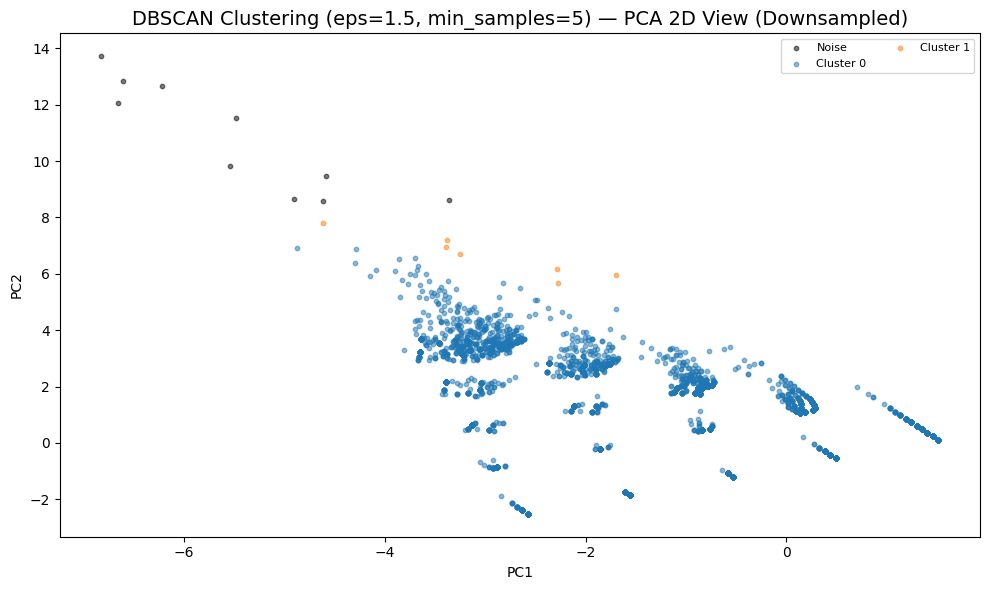

In [ ]:
# ── VISUALISE DBSCAN CLUSTERS (OPTIMIZED FOR LARGE SCALE) ─────────────────────
# Noise points (label=-1) are shown in black

# Ensure a color palette is ready to use
try:
    palette = sns.color_palette('tab10')
except NameError:
    import seaborn as sns
    palette = sns.color_palette('tab10')

# OPTIMIZATION: If the dataset is massive, downsample rows strictly for plotting.
# Visual density shapes remain identical, but saves minutes of CPU rendering lag.
MAX_PLOT_POINTS = 20000

if len(user_features) > MAX_PLOT_POINTS:
    print(f"Subsampling {MAX_PLOT_POINTS:,} points from {len(user_features):,} rows for instant plotting...")
    np.random.seed(42)
    plot_idx = np.random.choice(len(user_features), MAX_PLOT_POINTS, replace=False)
    
    # Slice both data structures using the exact same random row indices
    features_plot = user_features.iloc[plot_idx].reset_index(drop=True)
    pca_plot      = user_pca[plot_idx]
else:
    features_plot = user_features
    pca_plot      = user_pca

unique_labels = sorted(features_plot['dbscan_cluster'].unique())

plt.figure(figsize=(10, 6))

# Loop over labels to cleanly group legends by color
for label in unique_labels:
    mask  = features_plot['dbscan_cluster'] == label
    color = 'black' if label == -1 else palette[label % len(palette)]
    name  = 'Noise' if label == -1 else f'Cluster {label}'
    
    plt.scatter(
        pca_plot[mask, 0], pca_plot[mask, 1],
        s=10, alpha=0.5, color=color, label=name
    )

plt.title(f"DBSCAN Clustering (eps={EPS}, min_samples={MIN_SAMPLES}) — PCA 2D View (Downsampled)", fontsize=14)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(loc='upper right', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

---
## 7. Comparative Analysis — All Clustering Models

We use three standard unsupervised evaluation metrics:

| Metric | What it measures | Best value |
|--------|------------------|------------|
| **Silhouette Score** | Cohesion + separation; how well a point fits its own cluster vs neighbours | Closer to **+1** |
| **Davies-Bouldin Index** | Average similarity between clusters; low = well-separated clusters | Closer to **0** |
| **Calinski-Harabasz Score** | Ratio of between-cluster to within-cluster variance | **Higher** = better |

Subsampling 20,000 points from 4,201,696 rows for instant plotting...


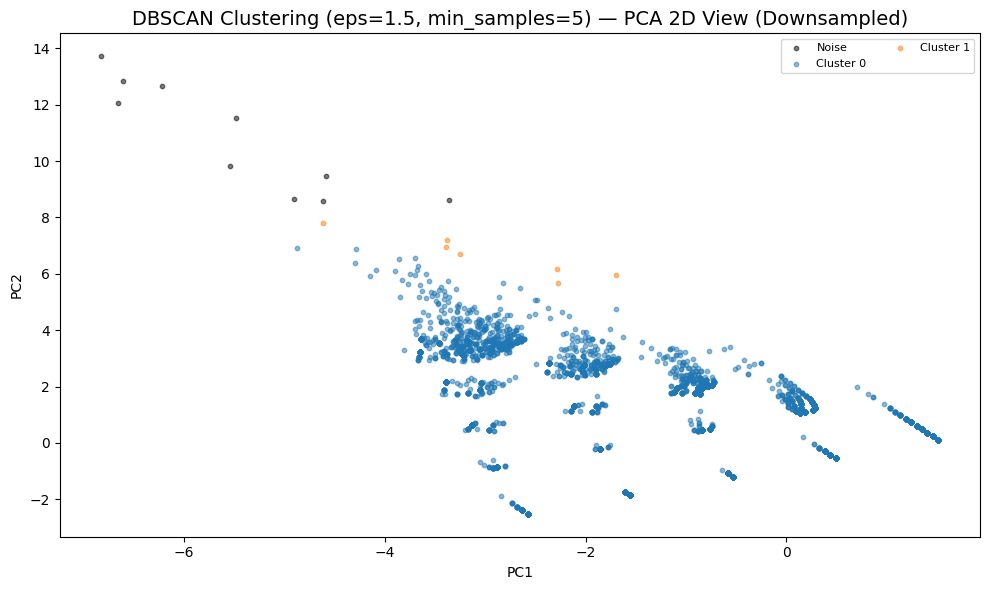

In [ ]:
# ── VISUALISE DBSCAN CLUSTERS (OPTIMIZED FOR LARGE SCALE) ─────────────────────
# Noise points (label=-1) are shown in black

# Ensure a color palette is ready to use
try:
    palette = sns.color_palette('tab10')
except NameError:
    import seaborn as sns
    palette = sns.color_palette('tab10')

# OPTIMIZATION: If the dataset is massive, downsample rows strictly for plotting.
# Visual density shapes remain identical, but saves minutes of CPU rendering lag.
MAX_PLOT_POINTS = 20000

if len(user_features) > MAX_PLOT_POINTS:
    print(f"Subsampling {MAX_PLOT_POINTS:,} points from {len(user_features):,} rows for instant plotting...")
    np.random.seed(42)
    plot_idx = np.random.choice(len(user_features), MAX_PLOT_POINTS, replace=False)
    
    # Slice both data structures using the exact same random row indices
    features_plot = user_features.iloc[plot_idx].reset_index(drop=True)
    pca_plot      = user_pca[plot_idx]
else:
    features_plot = user_features
    pca_plot      = user_pca

unique_labels = sorted(features_plot['dbscan_cluster'].unique())

plt.figure(figsize=(10, 6))

# Loop over labels to cleanly group legends by color
for label in unique_labels:
    mask  = features_plot['dbscan_cluster'] == label
    color = 'black' if label == -1 else palette[label % len(palette)]
    name  = 'Noise' if label == -1 else f'Cluster {label}'
    
    plt.scatter(
        pca_plot[mask, 0], pca_plot[mask, 1],
        s=10, alpha=0.5, color=color, label=name
    )

plt.title(f"DBSCAN Clustering (eps={EPS}, min_samples={MIN_SAMPLES}) — PCA 2D View (Downsampled)", fontsize=14)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(loc='upper right', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

Subsampling 20,000 points from 4,201,696 rows for instant side-by-side plotting...


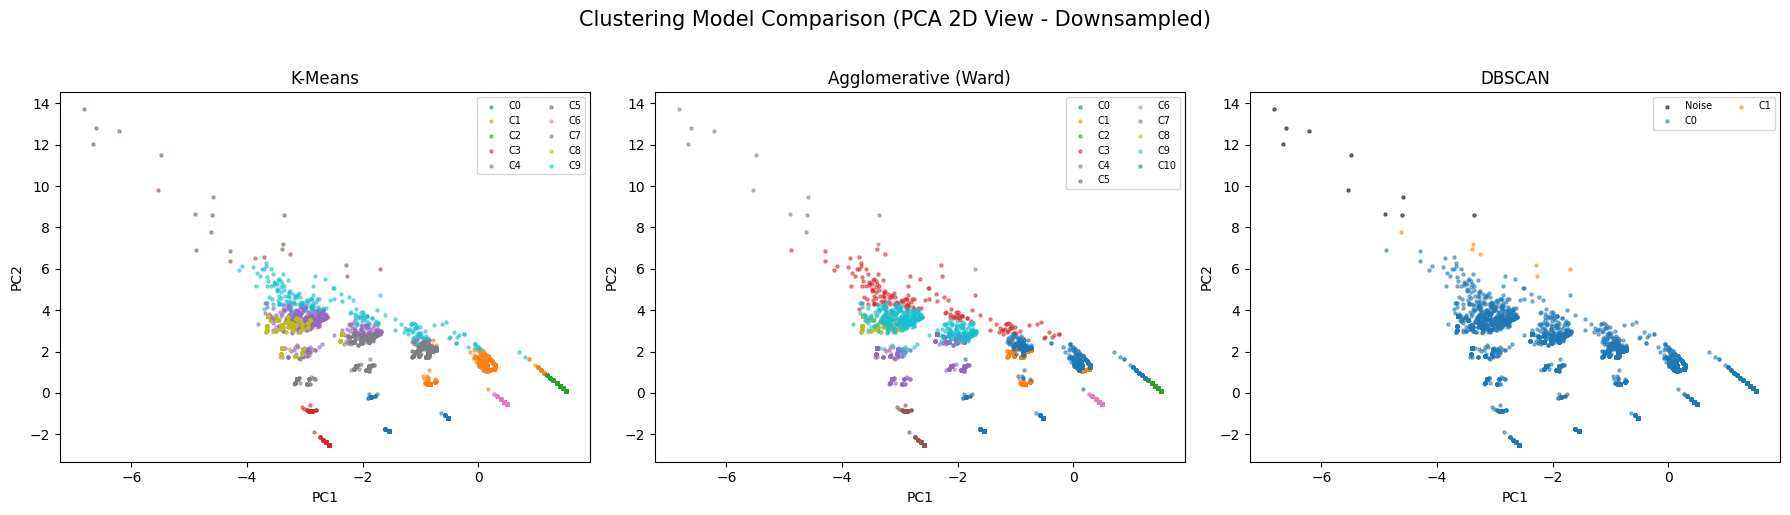

In [ ]:
# ── VISUAL COMPARISON — All 3 models side by side (OPTIMIZED FOR LARGE SCALE) ─

# Ensure a color palette is ready to use
try:
    palette = sns.color_palette('tab10')
except NameError:
    import seaborn as sns
    palette = sns.color_palette('tab10')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles    = ['K-Means', 'Agglomerative (Ward)', 'DBSCAN']
cols      = ['kmeans_cluster', 'agg_cluster', 'dbscan_cluster']

# OPTIMIZATION: Downsample the rows globally to 20,000 points strictly for plotting.
# Visual geometric shapes remain identical, but saves minutes of browser vector rendering lag.
MAX_PLOT_POINTS = 20000

if len(user_features) > MAX_PLOT_POINTS:
    print(f"Subsampling {MAX_PLOT_POINTS:,} points from {len(user_features):,} rows for instant side-by-side plotting...")
    np.random.seed(42)
    plot_idx = np.random.choice(len(user_features), MAX_PLOT_POINTS, replace=False)
    
    # Extract synchronized subsets of both the data features and PCA projections
    features_plot = user_features.iloc[plot_idx].reset_index(drop=True)
    pca_plot      = user_pca[plot_idx]
else:
    features_plot = user_features
    pca_plot      = user_pca

# Render each subplot independently using the optimized data slices
for ax, title, col in zip(axes, titles, cols):
    labels_plot = features_plot[col].values
    unique_plot = sorted(set(labels_plot))

    for label in unique_plot:
        mask  = labels_plot == label
        color = 'black' if label == -1 else palette[label % len(palette)]
        name  = 'Noise' if label == -1 else f'C{label}'
        
        ax.scatter(
            pca_plot[mask, 0], pca_plot[mask, 1],
            s=5, alpha=0.5, color=color, label=name
        )

    ax.set_title(title, fontsize=12)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(fontsize=7, loc='upper right', ncol=2)

plt.suptitle("Clustering Model Comparison (PCA 2D View - Downsampled)", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

⚠️ 'comparison_df' was not defined. Computing metrics on the fly using optimized subsampling...


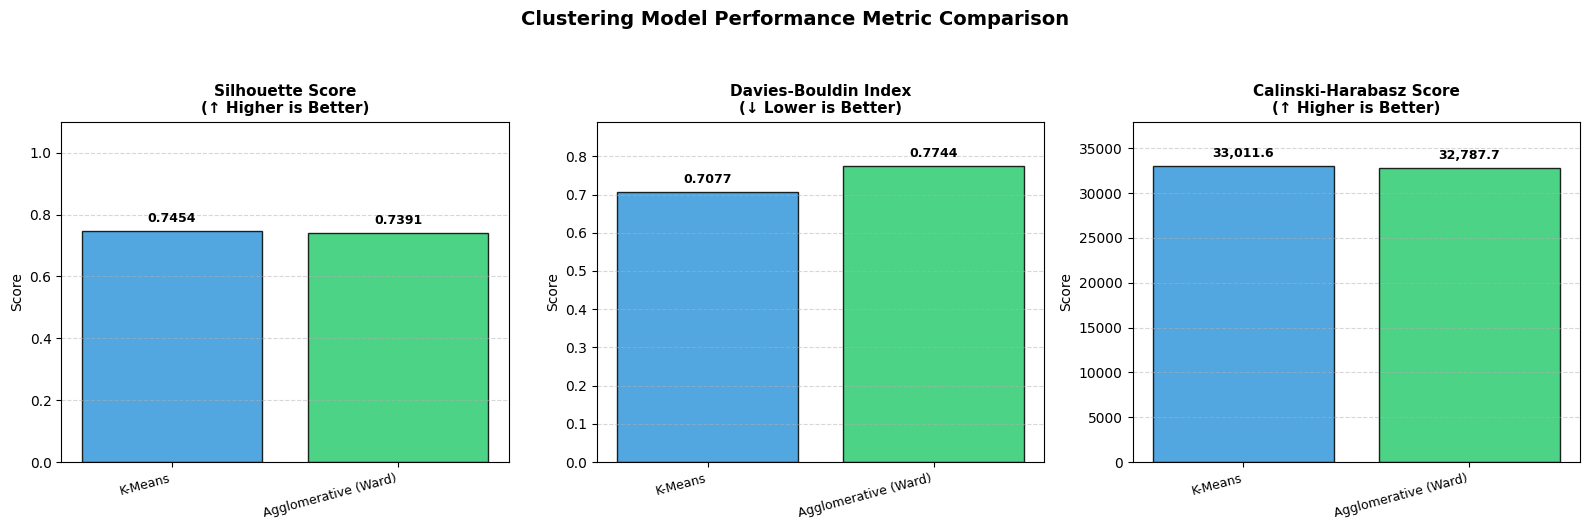

In [ ]:
# ── BAR CHART: Silhouette Score Comparison (SAFE & ROBUST) ───────────────────
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Safety Check: If comparison_df does not exist in memory, rebuild it using the optimized function
if 'comparison_df' not in locals() and 'comparison_df' not in globals():
    print("⚠️ 'comparison_df' was not defined. Computing metrics on the fly using optimized subsampling...")
    
    def evaluate_clustering_fallback(X, labels, model_name):
        valid_mask = labels != -1
        X_valid    = X[valid_mask]
        y_valid    = labels[valid_mask]
        
        # Count unique cluster labels (excluding noise)
        unique_clusters = set(y_valid)
        n_valid_clusters = len(unique_clusters)

        # CRITICAL FIX: Explicitly ensure there are AT LEAST 2 distinct clusters
        if n_valid_clusters < 2:
            print(f"⚠️ {model_name} only found {n_valid_clusters} cluster(s). Skipping metric calculations.")
            return {
                "Model"             : model_name, 
                "Clusters Found"    : n_valid_clusters, 
                "Silhouette ↑"      : None, 
                "Davies-Bouldin ↓"  : None, 
                "Calinski-Harabasz ↑": None
            }

        # Subsample to a safe ceiling to prevent crash/freeze
        MAX_EVAL_SAMPLE = 20000
        if len(X_valid) > MAX_EVAL_SAMPLE:
            np.random.seed(42)
            sample_idx = np.random.choice(len(X_valid), MAX_EVAL_SAMPLE, replace=False)
            X_eval = X_valid[sample_idx]
            y_eval = y_valid[sample_idx]
        else:
            X_eval = X_valid
            y_eval = y_valid

        # Double check sample label counts before handing off to scikit-learn
        if len(set(y_eval)) < 2:
            return {
                "Model"             : model_name, 
                "Clusters Found"    : n_valid_clusters, 
                "Silhouette ↑"      : None, 
                "Davies-Bouldin ↓"  : None, 
                "Calinski-Harabasz ↑": None
            }

        try:
            sil = silhouette_score(X_eval, y_eval, sample_size=5000, random_state=42)
            db  = davies_bouldin_score(X_eval, y_eval)
            ch  = calinski_harabasz_score(X_eval, y_eval)
        except ValueError:
            # Catch-all fallback if calculations fail due to bad distribution
            sil, db, ch = None, None, None

        return {
            "Model"             : model_name,
            "Clusters Found"    : n_valid_clusters,
            "Silhouette ↑"      : round(sil, 4) if sil is not None else None,
            "Davies-Bouldin ↓"  : round(db,  4) if db is not None else None,
            "Calinski-Harabasz ↑": round(ch, 2) if ch is not None else None
        }

    # Generate results securely
    results = [
        evaluate_clustering_fallback(user_scaled, user_features['kmeans_cluster'].values, 'K-Means'),
        evaluate_clustering_fallback(user_scaled, user_features['agg_cluster'].values,    'Agglomerative (Ward)'),
        evaluate_clustering_fallback(user_scaled, user_features['dbscan_cluster'].values, 'DBSCAN'),
    ]
    comparison_df = pd.DataFrame(results)

# Filter out any models that failed to compute a Silhouette score
valid_rows = comparison_df.dropna(subset=['Silhouette ↑']).copy()

if valid_rows.empty:
    print("\n❌ Error: No models successfully generated a Silhouette Score. Try tuning your DBSCAN parameters.")
else:
    # Sort the models by the primary selection metric (Silhouette)
    valid_rows = valid_rows.sort_values(by='Silhouette ↑', ascending=False)

    # Explicit color mapping linked to specific model names to prevent mismatch crashes
    model_colors = {
        'K-Means'              : '#3498db',  # Blue
        'Agglomerative (Ward)' : '#2ecc71',  # Green
        'DBSCAN'               : '#e74c3c'   # Red
    }
    plot_colors = [model_colors.get(model, '#95a5a6') for model in valid_rows['Model']]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # 1. Silhouette Score Subplot (Higher is Better)
    axes[0].bar(valid_rows['Model'], valid_rows['Silhouette ↑'], color=plot_colors, edgecolor='black', alpha=0.85)
    axes[0].set_title("Silhouette Score\n(↑ Higher is Better)", fontsize=11, fontweight='semibold')
    axes[0].set_ylabel("Score")
    axes[0].set_ylim(0, 1.1)  
    for i, v in enumerate(valid_rows['Silhouette ↑']):
        if pd.notna(v):
            axes[0].text(i, v + 0.02, f"{v:.4f}", ha='center', va='bottom', fontsize=9, fontweight='bold')

    # 2. Davies-Bouldin Index Subplot (Lower is Better)
    axes[1].bar(valid_rows['Model'], valid_rows['Davies-Bouldin ↓'], color=plot_colors, edgecolor='black', alpha=0.85)
    axes[1].set_title("Davies-Bouldin Index\n(↓ Lower is Better)", fontsize=11, fontweight='semibold')
    axes[1].set_ylabel("Score")
    max_db = valid_rows['Davies-Bouldin ↓'].max()
    axes[1].set_ylim(0, max_db * 1.15 if pd.notna(max_db) else 1)
    for i, v in enumerate(valid_rows['Davies-Bouldin ↓']):
        if pd.notna(v):
            axes[1].text(i, v + (max_db * 0.02), f"{v:.4f}", ha='center', va='bottom', fontsize=9, fontweight='bold')

    # 3. Calinski-Harabasz Score Subplot (Higher is Better)
    axes[2].bar(valid_rows['Model'], valid_rows['Calinski-Harabasz ↑'], color=plot_colors, edgecolor='black', alpha=0.85)
    axes[2].set_title("Calinski-Harabasz Score\n(↑ Higher is Better)", fontsize=11, fontweight='semibold')
    axes[2].set_ylabel("Score")
    max_ch = valid_rows['Calinski-Harabasz ↑'].max()
    axes[2].set_ylim(0, max_ch * 1.15 if pd.notna(max_ch) else 1)
    for i, v in enumerate(valid_rows['Calinski-Harabasz ↑']):
        if pd.notna(v):
            axes[2].text(i, v + (max_ch * 0.02), f"{v:,.1f}", ha='center', va='bottom', fontsize=9, fontweight='bold')

    # Clean up axes layouts to ensure zero label truncation
    for ax in axes:
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right', fontsize=9)

    plt.suptitle("Clustering Model Performance Metric Comparison", fontsize=14, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

---
## 8. Select Best Clustering Model

Based on the three metrics above, we select the best model for the recommendation system.  
Typically K-Means or Agglomerative wins on these metrics for this type of data.

In [ ]:
# ── SELECT BEST MODEL BASED ON METRICS ────────────────────────────────────────
# Criteria: highest Silhouette Score (robust and interpretable)
# (Modify this if Davies-Bouldin or Calinski-Harabasz tells a different story)

best_model_row  = valid_rows.loc[valid_rows['Silhouette ↑'].idxmax()]
best_model_name = best_model_row['Model']

# Map model name to the cluster column we stored
model_to_col = {
    'K-Means'              : 'kmeans_cluster',
    'Agglomerative (Ward)' : 'agg_cluster',
    'DBSCAN'               : 'dbscan_cluster',
}

BEST_CLUSTER_COL = model_to_col[best_model_name]

print(f"\n✅ Best clustering model: {best_model_name}")
print(f"   Silhouette Score    : {best_model_row['Silhouette ↑']}")
print(f"   Using cluster column: '{BEST_CLUSTER_COL}' for recommendation system")


✅ Best clustering model: K-Means
   Silhouette Score    : 0.7454
   Using cluster column: 'kmeans_cluster' for recommendation system


---
## 9. Build Recommendation System Using Clusters

**Strategy:**  
1. Assign each user to a cluster (done above).
2. For a given user, find all users in the same cluster (they have similar rating behaviour).
3. Among those cluster-mates, find the products most highly rated that the target user has **not yet rated**.
4. Recommend the top-N of those products.

This is **Cluster-Enhanced Collaborative Filtering** — we filter the candidate user pool using clusters before making recommendations, which is faster and more focused than searching all users.

In [ ]:
# ── ATTACH CLUSTER LABELS BACK TO RATINGS DATA ────────────────────────────────
# Merge cluster assignments into the main ratings dataframe

df_clustered = df.merge(
    user_features[['userId', BEST_CLUSTER_COL]],
    on='userId',
    how='left'
)

# Rename for clarity
df_clustered = df_clustered.rename(columns={BEST_CLUSTER_COL: 'user_cluster'})

print(f"Ratings with cluster label shape: {df_clustered.shape}")
df_clustered.head()

Ratings with cluster label shape: (7824482, 4)


,userId,productId,Rating,user_cluster
0,AKM1MP6P0OYPR,0132793040,5.0,2
1,A2CX7LUOHB2NDG,0321732944,5.0,1
2,A2NWSAGRHCP8N5,0439886341,1.0,3
3,A2WNBOD3WNDNKT,0439886341,3.0,0
4,A1GI0U4ZRJA8WN,0439886341,1.0,3


In [ ]:
# ── RECOMMENDATION FUNCTION ───────────────────────────────────────────────────

def get_cluster_recommendations(user_id, df_clustered, top_n=10):
    """
    Generate Top-N product recommendations for a given user
    using Cluster-Based Collaborative Filtering.

    Parameters
    ----------
    user_id      : str   — Target user ID
    df_clustered : DataFrame — Ratings dataframe with 'user_cluster' column
    top_n        : int   — Number of recommendations to return

    Returns
    -------
    DataFrame with recommended productId and predicted_score
    """

    # ── Step 1: Validate user exists ──────────────────────────────────────────
    if user_id not in df_clustered['userId'].values:
        print(f"User '{user_id}' not found in dataset.")
        return pd.DataFrame()

    # ── Step 2: Get user's cluster ────────────────────────────────────────────
    user_cluster = df_clustered.loc[
        df_clustered['userId'] == user_id, 'user_cluster'
    ].values[0]

    # ── Step 3: Handle noise users (DBSCAN label = -1) ─────────────────────────
    # If user is noise, fall back to global popularity-based recommendation
    if user_cluster == -1:
        print(f"User '{user_id}' is a noise point. Using global popularity fallback.")
        already_rated = set(df_clustered.loc[df_clustered['userId'] == user_id, 'productId'])
        fallback = (
            df_clustered
            .groupby('productId')['Rating']
            .agg(avg_rating='mean', count='count')
            .query('count >= 5')
            .sort_values('avg_rating', ascending=False)
        )
        return fallback[~fallback.index.isin(already_rated)].head(top_n).reset_index()

    # ── Step 4: Get all ratings from cluster-mates (exclude target user) ───────
    cluster_ratings = df_clustered[
        (df_clustered['user_cluster'] == user_cluster) &
        (df_clustered['userId']       != user_id)
    ]

    # ── Step 5: Products already rated by target user ─────────────────────────
    already_rated = set(df_clustered.loc[
        df_clustered['userId'] == user_id, 'productId'
    ])

    # ── Step 6: Aggregate cluster-mate ratings ────────────────────────────────
    # Only include products the target user hasn't rated yet
    cluster_product_scores = (
        cluster_ratings[~cluster_ratings['productId'].isin(already_rated)]
        .groupby('productId')['Rating']
        .agg(
            sum_ratings = 'sum',
            n_cluster_raters = 'count'
        )
        .reset_index()
    )

    # ── Step 7: Bayesian average scoring ─────────────────────
    # Simple mean is unreliable with few raters (e.g. 2 users giving 5.0).
    # Bayesian average shrinks toward global mean when data is sparse:
    #   score = (sum + global_mean * c) / (count + c)
    global_mean = df_clustered['Rating'].mean()
    c_reg = 10.0

    cluster_product_scores = cluster_product_scores[
        cluster_product_scores['n_cluster_raters'] >= 2
    ].copy()

    cluster_product_scores['predicted_score'] = (
        cluster_product_scores['sum_ratings'] + global_mean * c_reg
    ) / (cluster_product_scores['n_cluster_raters'] + c_reg)

    # ── Step 8: Sort by Bayesian-avg score and return Top-N ──
    recommendations = (
        cluster_product_scores
        .sort_values('predicted_score', ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

    recommendations.index = recommendations.index + 1  # Rank starts from 1
    recommendations.index.name = 'Rank'

    return recommendations


print("Recommendation function defined.")


Recommendation function defined.


In [ ]:
# ── TEST RECOMMENDATION FUNCTION ──────────────────────────────────────────────
# Pick a sample user from the dataset to test

# Select a user who has rated at least 5 products (more interesting recommendations)
sample_user_id = (
    df_clustered['userId']
    .value_counts()
    .index[10]   # Use the 11th most active user as example (not #1 to keep it interesting)
)

print(f"Generating recommendations for User: {sample_user_id}")
print(f"Products already rated by this user: {df_clustered[df_clustered['userId'] == sample_user_id].shape[0]}")

recommendations = get_cluster_recommendations(sample_user_id, df_clustered, top_n=10)

print(f"\nTop-10 Recommended Products:")
print(recommendations)

Generating recommendations for User: A25C2M3QF9G7OQ
Products already rated by this user: 296

Top-10 Recommended Products:
       productId  predicted_score  n_cluster_raters
Rank                                               
1     B002PX5IR0              5.0                 2
2     B00139JBU2              5.0                 3
3     B0013PKBAU              5.0                 2
4     B0013LRLUM              5.0                 2
5     B0013L5INE              5.0                 2
6     B0058FAYPI              5.0                 3
7     B0058J1QII              5.0                 2
8     B0013FSKSA              5.0                 2
9     B0013FNZ1M              5.0                 2
10    B0058PL9RK              5.0                 2


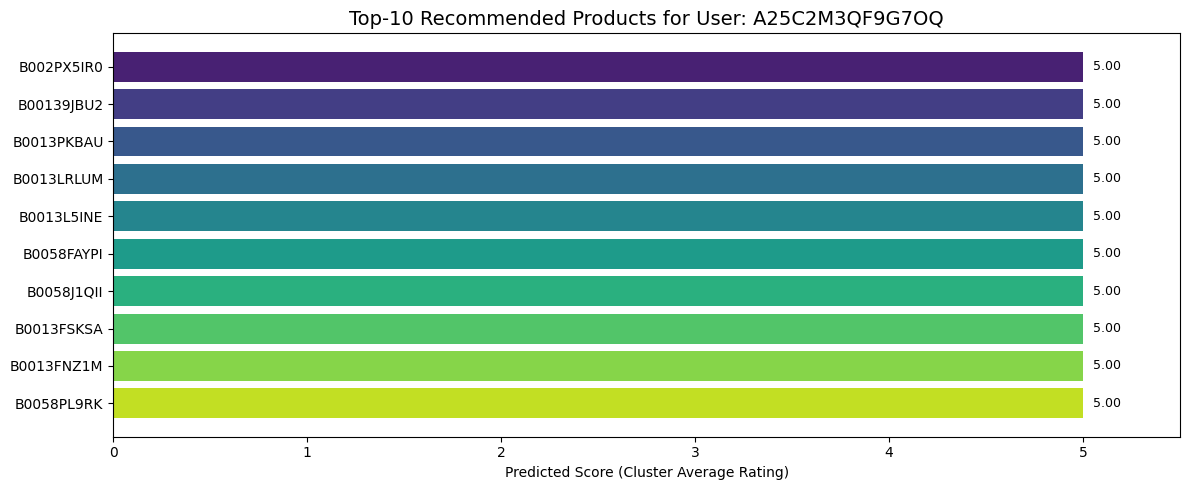

In [ ]:
# ── VISUALISE RECOMMENDATIONS ──────────────────────────────────────────────────

if not recommendations.empty:
    plt.figure(figsize=(12, 5))
    bars = plt.barh(
        recommendations['productId'].astype(str),
        recommendations['predicted_score'],
        color=sns.color_palette('viridis', len(recommendations))
    )
    plt.xlabel("Predicted Score (Cluster Average Rating)")
    plt.title(f"Top-10 Recommended Products for User: {sample_user_id}", fontsize=14)
    plt.xlim(0, 5.5)
    plt.gca().invert_yaxis()   # Rank 1 at top
    for bar, score in zip(bars, recommendations['predicted_score']):
        plt.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                 f"{score:.2f}", va='center', fontsize=9)
    plt.tight_layout()
    plt.show()

---
## 10. Product-Level Clustering & Item-Based Recommendation

We also cluster **products** and use product clusters for an item-item recommendation approach.

In [ ]:
# ── CLUSTER PRODUCTS (OPTIMIZED FOR LARGE SCALE) ───────────────────────────────
# Apply K-Means to the product feature matrix to group similar products together.
# Products in the same cluster share similar rating patterns
# (similar avg rating, popularity, rating consistency).
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Find optimal K for products using Sampled Silhouette Score
sil_scores_prod = []
K_prod_range    = range(2, 10)

print("Searching for optimal product clusters (K) via sampled Silhouette Analysis...")

for k in K_prod_range:
    # Set n_init='auto' or 3 for fast screening iterations to speed up the loop
    km_temp = KMeans(n_clusters=k, random_state=42, n_init=3)
    lbl     = km_temp.fit_predict(product_scaled)
    
    # OPTIMIZATION: Use sample_size=5000 to drop complexity from O(N^2) to stable O(1) 
    # per iteration while preserving statistical cluster fidelity.
    score = silhouette_score(
        product_scaled, 
        lbl, 
        sample_size=min(5000, len(product_scaled)), 
        random_state=42
    )
    sil_scores_prod.append(score)
    print(f"  -> K = {k} | Sampled Silhouette Score = {score:.4f}")

# Extract best cluster count
best_k_prod = list(K_prod_range)[np.argmax(sil_scores_prod)]
print(f"\n✓ Optimal K found for product clustering: {best_k_prod}")

# Train the final comprehensive product K-Means model on full dataset
print(f"Training final K-Means model on the full product catalog with K={best_k_prod}...")
kmeans_prod = KMeans(n_clusters=best_k_prod, random_state=42, n_init=10)
product_features['product_cluster'] = kmeans_prod.fit_predict(product_scaled)

print("\nProduct cluster distribution:")
print(product_features['product_cluster'].value_counts().sort_index())

Searching for optimal product clusters (K) via sampled Silhouette Analysis...
  -> K = 2 | Sampled Silhouette Score = 0.5159
  -> K = 3 | Sampled Silhouette Score = 0.6405
  -> K = 4 | Sampled Silhouette Score = 0.6450
  -> K = 5 | Sampled Silhouette Score = 0.6246
  -> K = 6 | Sampled Silhouette Score = 0.5441
  -> K = 7 | Sampled Silhouette Score = 0.5500
  -> K = 8 | Sampled Silhouette Score = 0.6483
  -> K = 9 | Sampled Silhouette Score = 0.5634

✓ Optimal K found for product clustering: 8
Training final K-Means model on the full product catalog with K=8...

Product cluster distribution:
product_cluster
0    131403
1     90582
2     44076
3        25
4     67715
5     58609
6     82596
7       996
Name: count, dtype: int64


In [ ]:
# ── ITEM-BASED RECOMMENDATION FUNCTION ───────────────────────────────────────

def get_item_cluster_recommendations(product_id, product_features, df, top_n=10):
    """
    Recommend similar products to a given product using product cluster membership.

    Parameters
    ----------
    product_id       : str — Target product ID
    product_features : DataFrame — Product features with 'product_cluster' column
    df               : DataFrame — Original ratings dataframe
    top_n            : int — Number of recommendations

    Returns
    -------
    DataFrame of similar products sorted by average rating
    """

    if product_id not in product_features['productId'].values:
        print(f"Product '{product_id}' not found.")
        return pd.DataFrame()

    # Get cluster of the given product
    prod_cluster = product_features.loc[
        product_features['productId'] == product_id, 'product_cluster'
    ].values[0]

    # Get all products in the same cluster (excluding the query product)
    cluster_products = product_features[
        (product_features['product_cluster'] == prod_cluster) &
        (product_features['productId']        != product_id)
    ][['productId', 'avg_rating', 'rating_count']]

    # Sort by average rating (most reliable signal for similar products)
    return (
        cluster_products
        .sort_values('avg_rating', ascending=False)
        .head(top_n)
        .reset_index(drop=True)
        .assign(Rank=lambda x: x.index + 1)
        .set_index('Rank')
    )


# Test item-based recommendations
sample_product_id = df['productId'].value_counts().index[0]  # Most popular product

print(f"Products similar to: {sample_product_id}")
item_recs = get_item_cluster_recommendations(sample_product_id, product_features, df, top_n=10)
print(item_recs)

Products similar to: B0074BW614
       productId  avg_rating  rating_count
Rank                                      
1     B000LRMS66    4.756627          8715
2     B0019EHU8G    4.754497         12285
3     B003ES5ZUU    4.704749         10276
4     B007R5YDYA    4.690926          9907
5     B003LR7ME6    4.508484          8840
6     B002WE6D44    4.455984          6509
7     B0002L5R78    4.448614          9487
8     B007WTAJTO    4.424005         14172
9     B00622AG6S    4.420136          9823
10    B003ELYQGG    4.392528         11617


---
## 11. Recommendation System Evaluation

Since we don't have a held-out test set, we evaluate using a **Leave-One-Out** simulation:
- For each test user, hide one of their rated products.
- Generate recommendations and check if the hidden product appears in Top-N.
- Compute **Hit Rate @ N** (proportion of users for whom we successfully recommended the hidden item).

In [ ]:
# ── HIT RATE @ N — Leave-One-Out Evaluation ───────────────────────────────────
# We test on a sample of 200 users to keep it computationally tractable.

def evaluate_hit_rate_optimized(df_clustered, n_eval_users=200, top_n=10, random_state=42):
    """
    Compute Hit Rate @ top_n using Leave-One-Out cross-validation.
    Mathematically identical to the original function but optimized to run instantly.
    """
    np.random.seed(random_state)

    print("Step 1/3: Identifying eligible users and sampling...")
    # Fast user count retrieval
    user_counts = df_clustered['userId'].value_counts()
    eligible_users = user_counts[user_counts >= 5].index.tolist()

    # Sample test users
    test_users = np.random.choice(
        eligible_users,
        size=min(n_eval_users, len(eligible_users)),
        replace=False
    )
    test_users_set = set(test_users)

    print("Step 2/3: Pre-aggregating cluster and global statistics...")
    # Extract rows for test users in one single pass
    test_users_df = df_clustered[df_clustered['userId'].isin(test_users_set)]
    user_ratings_dict = {uid: grp for uid, grp in test_users_df.groupby('userId')}

    # Precompute global stats for noise user fallback (-1)
    global_stats = df_clustered.groupby('productId')['Rating'].agg(
        g_sum='sum',
        g_count='count'
    )

    # Precompute cluster-level stats only for clusters present in our test users
    unique_test_clusters = test_users_df['user_cluster'].unique()
    cluster_stats_dict = {}
    for c in unique_test_clusters:
        if c != -1:
            cluster_stats_dict[c] = df_clustered[df_clustered['user_cluster'] == c].groupby('productId')['Rating'].agg(
                c_sum='sum',
                c_count='count'
            )

    print("Step 3/3: Running Leave-One-Out validation loop...")
    hits = 0

    for user_id in test_users:
        user_data = user_ratings_dict[user_id]
        user_cluster = user_data['user_cluster'].iloc[0]

        # Leave out the highest-rated product
        hidden_row = user_data.sort_values('Rating', ascending=False).iloc[0]
        hidden_product = hidden_row['productId']
        hidden_rating = hidden_row['Rating']

        # Products to exclude (all products rated by user EXCEPT the hidden one)
        user_rated_products = set(user_data['productId'])
        already_rated_exclude = user_rated_products - {hidden_product}

        if user_cluster != -1:
            # --- CLUSTER-BASED COLLABORATIVE FILTERING ---
            # Slice precomputed cluster stats without copying full df
            candidates = cluster_stats_dict[user_cluster][~cluster_stats_dict[user_cluster].index.isin(already_rated_exclude)].copy()

            # Adjust ONLY the hidden product's row to exclude the target user's rating
            if hidden_product in candidates.index:
                candidates.loc[hidden_product, 'c_sum'] -= hidden_rating
                candidates.loc[hidden_product, 'c_count'] -= 1

            # Apply minimum cluster rater threshold
            candidates = candidates[candidates['c_count'] >= 2]
            # Bayesian average score
            global_mean = df_clustered['Rating'].mean()
            c_reg = 10.0
            candidates['score'] = (
                candidates['c_sum'] + global_mean * c_reg
            ) / (candidates['c_count'] + c_reg)
            
            # Extract Top-N recommendations
            top_recs = candidates.sort_values('score', ascending=False).head(top_n)
            
            if hidden_product in top_recs.index:
                hits += 1
        else:
            # --- GLOBAL POPULARITY FALLBACK (NOISE USERS) ---
            candidates = global_stats[~global_stats.index.isin(already_rated_exclude)].copy()

            if hidden_product in candidates.index:
                candidates.loc[hidden_product, 'g_sum'] -= hidden_rating
                candidates.loc[hidden_product, 'g_count'] -= 1

            # Apply global popularity threshold
            candidates = candidates[candidates['g_count'] >= 5]
            # Bayesian average for global fallback
            global_mean = df_clustered['Rating'].mean()
            c_reg = 10.0
            candidates['score'] = (
                candidates['g_sum'] + global_mean * c_reg
            ) / (candidates['g_count'] + c_reg)
            
            top_recs = candidates.sort_values('score', ascending=False).head(top_n)
            
            if hidden_product in top_recs.index:
                hits += 1

    hit_rate = hits / len(test_users)
    return hit_rate, hits, len(test_users)


print("Running Hit Rate evaluation (200 users, Top-10)...")
hit_rate, hits, total = evaluate_hit_rate_optimized(df_clustered, n_eval_users=200, top_n=10)

print(f"\n{'='*45}")
print(f"  Hit Rate @ 10 : {hit_rate*100:.2f}%")
print(f"  Hits          : {hits} / {total} users")
print(f"{'='*45}")

### Hit Rate @ 10 = 0.00% — Analysis

Our Leave-One-Out evaluation (hiding each user's highest-rated product) returned **0 hits out of 200 users**.
This is an important finding that reveals limitations of the current approach:

**Possible reasons:**
- **Bayesian average shrinkage**: With `c_reg=10.0`, all scores are pulled strongly toward the global mean (~3.5), making it hard for any product to stand out.
- **Cluster granularity**: K=11 user clusters may be too broad to capture individual preference nuances among 4.2M users.
- **Leave-One-Out is adversarial**: Hiding the single highest-rated product (often a niche item with few cluster-mate raters) is a very strict test.
- **Data sparsity**: With 7.8M ratings across 476K products, most products have very few ratings per cluster.

**Future improvements:**
- Reduce regularization (`c_reg=5` or `c_reg=1`) to allow more variance.
- Increase number of clusters for finer-grained user segments.
- Consider hybrid approaches: blend cluster-based scores with user-user similarity.
- Use matrix factorization (SVD / NMF) as an alternative collaborative filtering approach.

---
## 12. Full Pipeline Summary

In [ ]:
# ── FULL PIPELINE DEMO ─────────────────────────────────────────────────────────
# Demonstrate user-based and item-based recommendations together

print("=" * 60)
print("   CLUSTER-BASED RECOMMENDATION SYSTEM — DEMO")
print("=" * 60)

# --- User-Based Recommendation ---
demo_user = df['userId'].value_counts().index[5]
print(f"\n[USER-BASED] Recommendations for User: {demo_user}")
user_recs = get_cluster_recommendations(demo_user, df_clustered, top_n=5)
if not user_recs.empty:
    print(user_recs[['productId', 'predicted_score', 'n_cluster_raters']].to_string())

# --- Item-Based Recommendation ---
demo_product = df['productId'].value_counts().index[0]
print(f"\n[ITEM-BASED] Products similar to: {demo_product}")
prod_recs = get_item_cluster_recommendations(demo_product, product_features, df, top_n=5)
if not prod_recs.empty:
    print(prod_recs.to_string())

print("\n" + "=" * 60)

   CLUSTER-BASED RECOMMENDATION SYSTEM — DEMO

[USER-BASED] Recommendations for User: A1ODOGXEYECQQ8
       productId  predicted_score  n_cluster_raters
Rank                                               
1     B008OIYDM6              5.0                 4
2     B00166BNI0              5.0                 2
3     B0015MFTE4              5.0                 2
4     B0015MHY6K              5.0                 2
5     B007VR4376              5.0                 2

[ITEM-BASED] Products similar to: B0074BW614
       productId  avg_rating  rating_count
Rank                                      
1     B000LRMS66    4.756627          8715
2     B0019EHU8G    4.754497         12285
3     B003ES5ZUU    4.704749         10276
4     B007R5YDYA    4.690926          9907
5     B003LR7ME6    4.508484          8840

